# Улучшение baseline-модели: стоимость квартир Яндекс Недвижимости

Baseline из первого спринта — CatBoost на очищенном датасете `clean_flats_dataset`.
Задача второго спринта — улучшить качество модели и зафиксировать все эксперименты в MLflow.

Этап 1 выполнен вне ноутбука: `mlflow_server/run_mlflow_server.sh` поднимает Tracking Server
и Model Registry (бэкенд — PostgreSQL, артефакты — S3), `mlflow_server/register_baseline_model.py`
регистрирует baseline как версию 1. Этапы 2–5 — здесь.

Основная метрика — **MAE** на тестовой выборке: средняя ошибка предсказания цены в рублях.
Дополнительно смотрим RMSE, MAPE и R².

### "Шапка" с названием проекта

В этой ячейке вы найдете оглавление и ключевые этапы работы, которые помогут вам ориентироваться в процессе выполнения проекта. Проект разделен на пять основных этапов, четыре из которых (этапы 2, 3, 4 и 5) вам предлагается выполнить в этом Jupyter Notebook:

- Подготовка среды MLflow - Первый шаг, подготовка и запуск сервисов MLflow, был выполнен вне ноутбука и оформлен в виде shell скрипта. Это основа для работы с экспериментами и логирования результатов ваших моделей.

- Этап 2 - Исследовательский Анализ Данных (EDA): На этом этапе вы проведете тщательный анализ данных, чтобы лучше понять их структуру и особенности.

- Этап 3 - Генерация Признаков и Обучение Модели: После анализа данных вы сгенерируете новые признаки и обучите модель, используя эти признаки.

- Этап 4 - Отбор Признаков и Обучение Модели: На этом шаге вы отберете наиболее значимые признаки и снова обучите модель для улучшения ее качества.

- Этап 5 - Подбор Гиперпараметров и Обучение Финальной Версии Модели: Финальный этап проекта посвящен оптимизации гиперпараметров для достижения максимального качества модели.

Для удобства навигации и организации работы, пожалуйста, следуйте оглавлению и рекомендациям, описанным в каждом этапе.

> ### Важно: Переобучение моделей
> На каждом этапе проекта, где требуется переобучение модели, важно не просто выполнить эту процедуру, но и тщательно проверить качество модели на соответствующих выборках. Это включает в себя анализ метрик качества, визуализацию результатов, сравнение с предыдущими моделями и, при необходимости, корректировку.

## Подготовка окружения

Подключаемся к MLflow (Tracking Server поднят на ВМ, бэкенд — PostgreSQL, артефакты — S3)
и работаем в одном эксперименте на все этапы.

In [1]:
%matplotlib inline

import json
import os
import time
import warnings
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

# доступы к БД и S3 лежат в .env в корне проекта
load_dotenv('../.env')
os.environ['MLFLOW_S3_ENDPOINT_URL'] = 'https://storage.yandexcloud.net'

TRACKING_URI = 'http://127.0.0.1:5000'
EXPERIMENT_NAME = 'flats_price_improvement'
REGISTRY_MODEL_NAME = 'flats_price_model'

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_registry_uri(TRACKING_URI)
EXPERIMENT_ID = mlflow.set_experiment(EXPERIMENT_NAME).experiment_id

ASSETS_DIR = 'assets'
os.makedirs(ASSETS_DIR, exist_ok=True)

print('experiment_id:', EXPERIMENT_ID)

experiment_id: 1


> ### Важно: Разделение выборок
> Перед началом выполнения вашего проекта важно правильно подготовить данные, разделив их на подвыборки. Это позволит оценить производительность модели более объективно и управлять риском переобучения. В зависимости от ваших целей и доступных данных, вы можете использовать различные стратегии разделения:

1. Разделение на train/val/test: Это классический подход, где данные делятся на три части. Обучающая выборка (train) используется для первичного обучения моделей, валидационная (val) - для настройки гиперпараметров и выбора лучшей модели, а тестовая (test) - для финальной оценки производительности модели. Такой подход идеален, если у вас достаточно данных, чтобы разделить их и каждая из выборок была репрезентативна.

2. Разделение на train/test с кросс-валидацией на train: Если данных недостаточно для трех подвыборок, можно ограничиться разделением на обучающую и тестовую выборки. В этом случае кросс-валидация на обучающей выборке поможет оценить стабильность модели и подобрать гиперпараметры.

Определение способа разделения данных: Выбор метода разбиения данных на подвыборки — train, validation и test — должен быть обоснован особенностями вашего набора данных и задачами проекта. Возможные методы разделения, включая различные стратегии и правила, подробно описаны в [документации scikit-learn по разбиению данных](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py). Вы можете следовать этим примерам или разработать собственный метод, исходя из специфики ваших данных.

Ваша задача - выбрать подходящий метод разделения данных исходя из объема и специфики ваших данных. Помните, что финальные метрики качества модели мы будем оценивать на тестовой выборке. Промежуточные результаты после каждого этапа проекта (например, после настройки гиперпараметров) следует оценивать на валидационной выборке, если таковая имеется. Это поможет вам корректно настроить модель перед финальной оценкой её производительности.

## Разделение выборки

Данных больше сотни тысяч строк, поэтому хватает разбиения train/test (80/20).
Гиперпараметры подбираем по кросс-валидации внутри train, тест трогаем только для финальной оценки —
так тестовая выборка остаётся честной.

Разбиение делаем ровно таким же, как в первом спринте (`test_size=0.2`, `random_state=42`),
иначе метрики baseline-модели нельзя будет сравнивать с новыми версиями.

In [2]:
# сделайте разделение изначального набора данных в этой ячейке

TABLE = 'clean_flats_dataset'
TARGET_COL = 'price'
DROP_COLS = ['id', 'flat_id', 'building_id']
CAT_COLS = ['building_type_int', 'is_apartment', 'studio', 'has_elevator']
TEST_SIZE = 0.2
RANDOM_STATE = 42


def load_data():
    """Читает очищенный датасет из личной БД."""
    password = quote_plus(os.environ['DB_DESTINATION_PASSWORD'])
    engine = create_engine(
        f"postgresql://{os.environ['DB_DESTINATION_USER']}:{password}"
        f"@{os.environ['DB_DESTINATION_HOST']}:{os.environ['DB_DESTINATION_PORT']}"
        f"/{os.environ['DB_DESTINATION_NAME']}"
    )
    df = pd.read_sql(f'select * from {TABLE}', engine)
    engine.dispose()
    return df


data = load_data()

# булевы флаги из БД приводим к int: так они одинаково выглядят и в статистиках, и после кодирования
bool_cols = data.select_dtypes('bool').columns
data[bool_cols] = data[bool_cols].astype(int)

print(f'строк: {len(data):,}, колонок: {data.shape[1]}, пропусков: {data.isna().sum().sum()}')
data.shape

строк: 82,877, колонок: 19, пропусков: 0


(82877, 19)

In [3]:
from sklearn.model_selection import train_test_split


def make_features(df):
    """Признаки: всё, кроме id-шников и цены. Категории приводим к строкам."""
    X = df.drop(columns=DROP_COLS + [TARGET_COL])
    for col in CAT_COLS:
        X[col] = X[col].astype(str)
    return X


train, test = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True)

X_train, y_train = make_features(train), train[TARGET_COL]
X_test, y_test = make_features(test), test[TARGET_COL]

print(f'train: {X_train.shape}, test: {X_test.shape}')

train: (66301, 15), test: (16576, 15)


In [4]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)


def eval_metrics(y_true, y_pred):
    """Метрики качества: основная - MAE, остальные для полноты картины."""
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(mean_squared_error(y_true, y_pred)) ** 0.5,
        'mape': float(mean_absolute_percentage_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


def show_metrics(name, metrics):
    print(name)
    print(f"  MAE  {metrics['mae']:,.0f} руб.")
    print(f"  RMSE {metrics['rmse']:,.0f} руб.")
    print(f"  MAPE {metrics['mape']:.2%}")
    print(f"  R2   {metrics['r2']:.4f}")


# метрики baseline-модели берём из MLflow: с ними сравниваем все следующие версии
baseline_run = mlflow.search_runs(
    experiment_ids=[EXPERIMENT_ID],
    filter_string="tags.mlflow.runName = 'baseline_model'",
).iloc[0]
BASELINE_METRICS = {m: float(baseline_run[f'metrics.{m}']) for m in ['mae', 'rmse', 'mape', 'r2']}
show_metrics('baseline', BASELINE_METRICS)

baseline
  MAE  1,664,928 руб.
  RMSE 2,062,755 руб.
  MAPE 16.23%
  R2   0.6475


#### Этап 2: Исследовательский Анализ Данных (EDA)
На этом этапе ваша задача - провести тщательный исследовательский анализ данных (EDA), чтобы глубже понять особенности и связи в предоставленном наборе данных. В процессе EDA вы должны обратить внимание на три ключевых аспекта, о которых мы говорили в теме 3 курса. Очень важно, чтобы все результаты вашего исследования, включая визуализации, статистический анализ и предварительные выводы, были аккуратно залогированы в MLflow.

Для более организованного исследования предлагаем следующие рекомендуемые шаги:
- Понимание данных: Первоначально ознакомьтесь с данными, изучите типы данных, проверьте наличие пропущенных значений.
- Визуализация данных: Используйте графики и диаграммы для визуализации распределений признаков и возможных взаимосвязей между ними.
- Статистический анализ: Примените статистические методы для изучения центральных тенденций, разброса и корреляций между признаками.
- Предварительные выводы: На основе проведённого анализа сформулируйте предварительные выводы о данных, которые помогут в дальнейшем этапе моделирования.

Помните, что EDA - это итеративный процесс, в котором вы можете возвращаться к предыдущим шагам для дополнительного анализа, если это будет необходимо. Все находки и выводы должны быть чётко зафиксированы и легко доступны для команды проекта.


In [5]:
# 2.1 Загрузка данных

data.head()

,id,flat_id,building_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator
0,23,28,21647,16,12.5,25.0,1,0,0,55.299999,15600000.0,2010,4,55.647091,37.503075,2.70,416,16,1
1,24,29,7535,2,6.0,35.0,3,0,0,57.000000,8550000.0,1968,1,55.636066,37.663082,2.64,214,9,1
2,25,30,11768,6,6.4,21.0,1,0,0,34.400002,6400000.0,1976,4,55.870430,37.595608,2.64,139,9,1
3,26,32,13156,12,8.6,19.1,1,0,0,38.900002,7700000.0,1980,4,55.891735,37.581287,2.64,446,16,1
4,27,33,9011,7,6.5,21.0,1,0,0,36.000000,5600000.0,1970,4,55.825794,37.823189,2.64,212,9,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82877 entries, 0 to 82876
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82877 non-null  int64  
 1   flat_id            82877 non-null  int64  
 2   building_id        82877 non-null  int64  
 3   floor              82877 non-null  int64  
 4   kitchen_area       82877 non-null  float64
 5   living_area        82877 non-null  float64
 6   rooms              82877 non-null  int64  
 7   is_apartment       82877 non-null  int64  
 8   studio             82877 non-null  int64  
 9   total_area         82877 non-null  float64
 10  price              82877 non-null  float64
 11  build_year         82877 non-null  int64  
 12  building_type_int  82877 non-null  int64  
 13  latitude           82877 non-null  float64
 14  longitude          82877 non-null  float64
 15  ceiling_height     82877 non-null  float64
 16  flats_count        828

In [7]:
overview = pd.DataFrame({
    'тип': data.dtypes.astype(str),
    'уникальных': data.nunique(),
    'пропусков': data.isna().sum(),
})
overview

,тип,уникальных,пропусков
id,int64,82877,0
flat_id,int64,82877,0
building_id,int64,15574,0
floor,int64,35,0
kitchen_area,float64,504,0
living_area,float64,1182,0
rooms,int64,5,0
is_apartment,int64,2,0
studio,int64,1,0
total_area,float64,1527,0


In [8]:
# 2.2. Общий обзор датасета

print(f'строк: {len(data):,}, колонок: {data.shape[1]}')
print(f'пропусков всего: {data.isna().sum().sum()}')
print(f'полных дублей (без id): {data.drop(columns=DROP_COLS).duplicated().sum()}')
data.describe().T

строк: 82,877, колонок: 19
пропусков всего: 0
полных дублей (без id): 0


,count,mean,std,min,25%,50%,75%,max
id,82877.0,4.143900e+04,2.392467e+04,1.000000,2.072000e+04,4.143900e+04,6.215800e+04,8.287700e+04
flat_id,82877.0,6.862641e+04,4.111185e+04,0.000000,3.290900e+04,6.737000e+04,1.037460e+05,1.413610e+05
building_id,82877.0,1.387263e+04,5.760212e+03,398.000000,9.166000e+03,1.351300e+04,1.851500e+04,2.462000e+04
floor,82877.0,7.179073e+00,4.888798e+00,1.000000,3.000000e+00,6.000000e+00,1.000000e+01,4.200000e+01
kitchen_area,82877.0,8.516164e+00,2.161487e+00,1.500000,6.500000e+00,8.500000e+00,1.000000e+01,1.584000e+01
living_area,82877.0,2.763463e+01,1.277581e+01,0.000000,1.900000e+01,2.820000e+01,3.440000e+01,6.900000e+01
rooms,82877.0,1.895725e+00,7.992924e-01,1.000000,1.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00
is_apartment,82877.0,2.545942e-03,5.039336e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
studio,82877.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
total_area,82877.0,5.017901e+01,1.488698e+01,11.500000,3.810000e+01,4.600000e+01,5.900000e+01,1.200000e+02


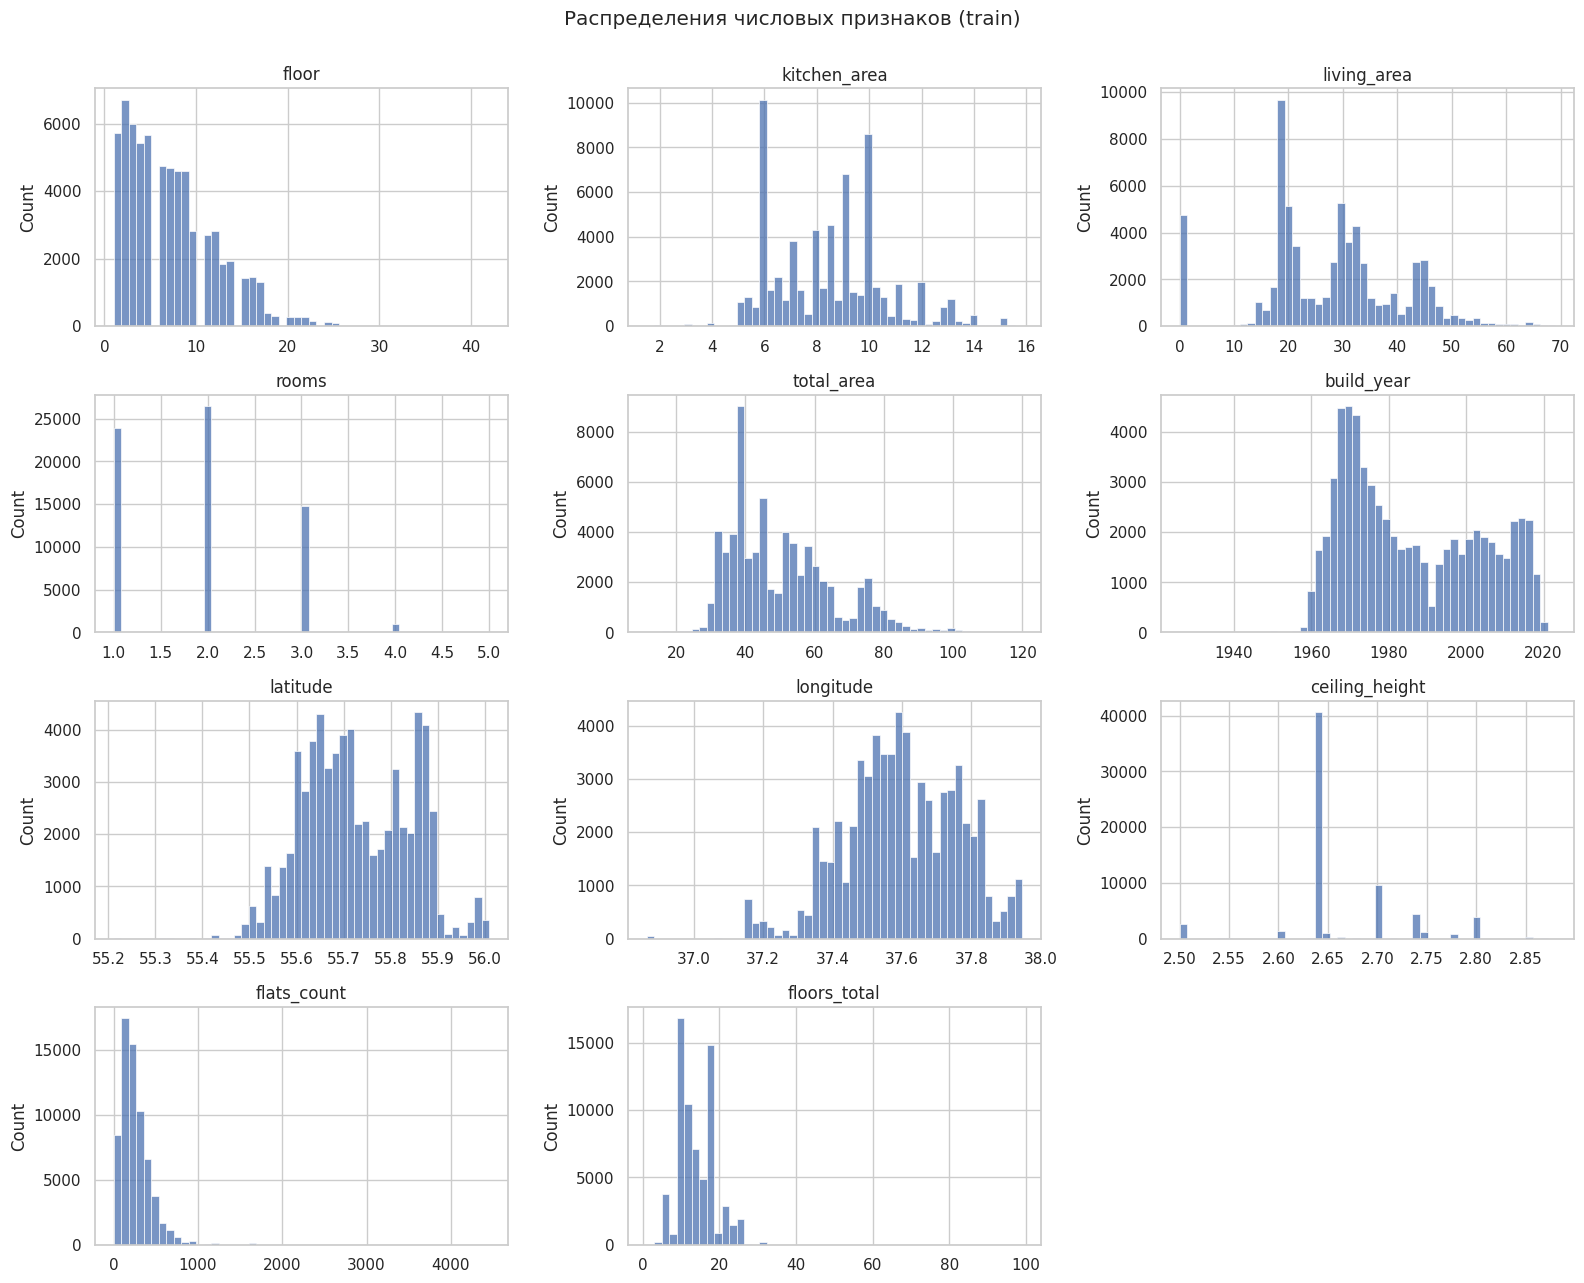

In [9]:
# 2.3 Анализ признаков для модели

num_cols = [c for c in X_train.columns if c not in CAT_COLS]

n_rows = int(np.ceil(len(num_cols) / 3))
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 3.2 * n_rows))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(train[col], bins=50, ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.set_xlabel('')
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
fig.suptitle('Распределения числовых признаков (train)', y=1.001)
fig.tight_layout()
fig.savefig(f'{ASSETS_DIR}/eda_numeric_distributions.png', dpi=110, bbox_inches='tight')
plt.show()

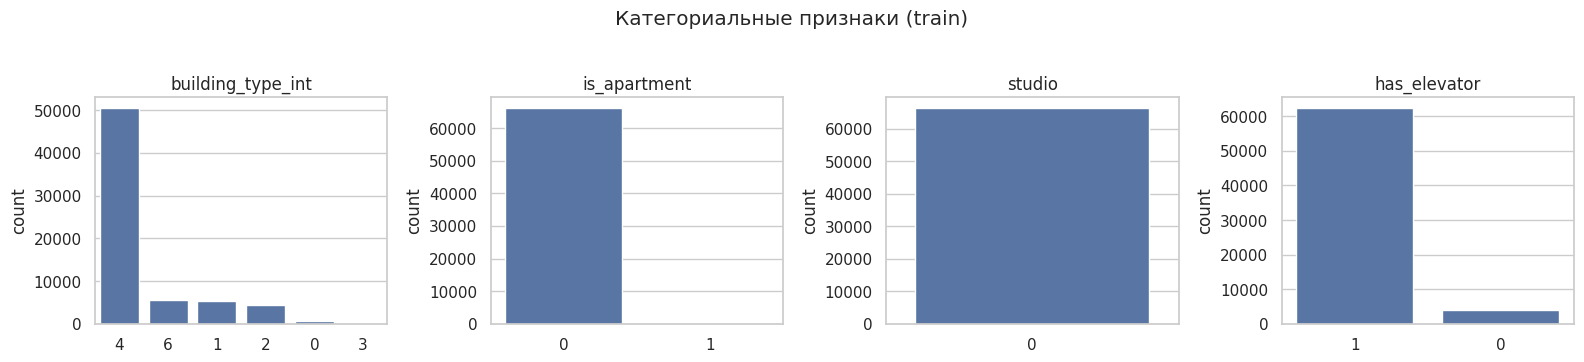

,count,unique,top,freq
building_type_int,66301,6,4,50508
is_apartment,66301,2,0,66133
studio,66301,1,0,66301
has_elevator,66301,2,1,62354


In [10]:
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(16, 3.5))
for ax, col in zip(axes, CAT_COLS):
    order = train[col].astype(str).value_counts().index
    sns.countplot(x=train[col].astype(str), order=order, ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.set_xlabel('')
fig.suptitle('Категориальные признаки (train)', y=1.03)
fig.tight_layout()
fig.savefig(f'{ASSETS_DIR}/eda_categorical.png', dpi=110, bbox_inches='tight')
plt.show()

train[CAT_COLS].astype(str).describe().T

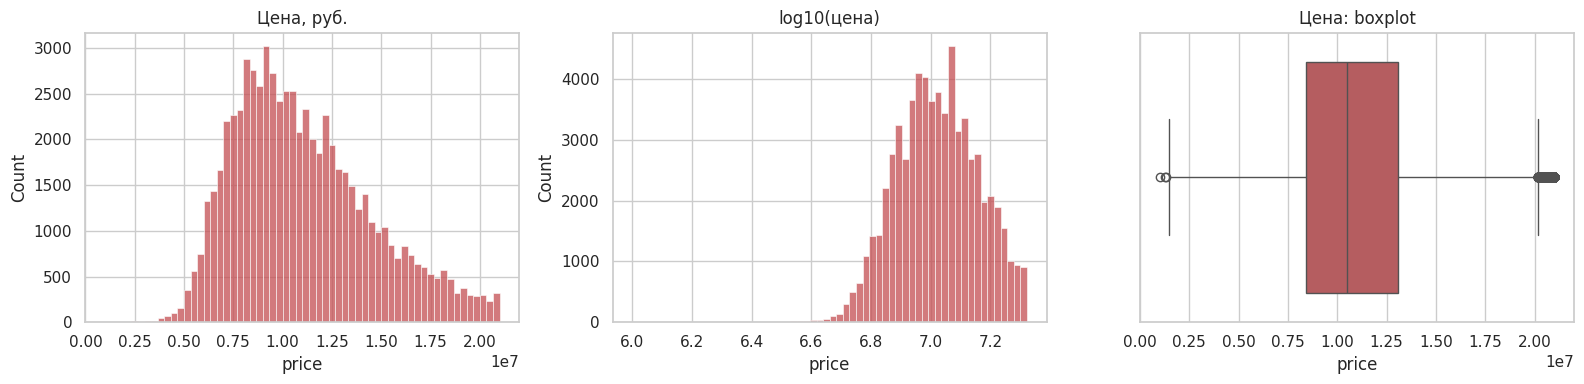

count        66,301
mean     11,026,867
std       3,483,242
min       1,000,000
1%        5,250,000
25%       8,400,000
50%      10,500,000
75%      13,100,000
95%      17,900,000
99%      20,000,000
max      21,000,000
Name: price, dtype: object

асимметрия (skew): 0.64
доля квартир дороже 95-го перцентиля (17,900,000 руб.): 4.9%


In [11]:
# 2.4 Анализ целевой переменной

price = train[TARGET_COL]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(price, bins=60, ax=axes[0], color='#C44E52')
axes[0].set_title('Цена, руб.')
sns.histplot(np.log10(price), bins=60, ax=axes[1], color='#C44E52')
axes[1].set_title('log10(цена)')
sns.boxplot(x=price, ax=axes[2], color='#C44E52')
axes[2].set_title('Цена: boxplot')
fig.tight_layout()
fig.savefig(f'{ASSETS_DIR}/eda_target.png', dpi=110, bbox_inches='tight')
plt.show()

print(price.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).apply(lambda v: f'{v:,.0f}'))
print(f'\nасимметрия (skew): {price.skew():.2f}')
q95 = price.quantile(0.95)
print(f'доля квартир дороже 95-го перцентиля ({q95:,.0f} руб.): {(price > q95).mean():.1%}')

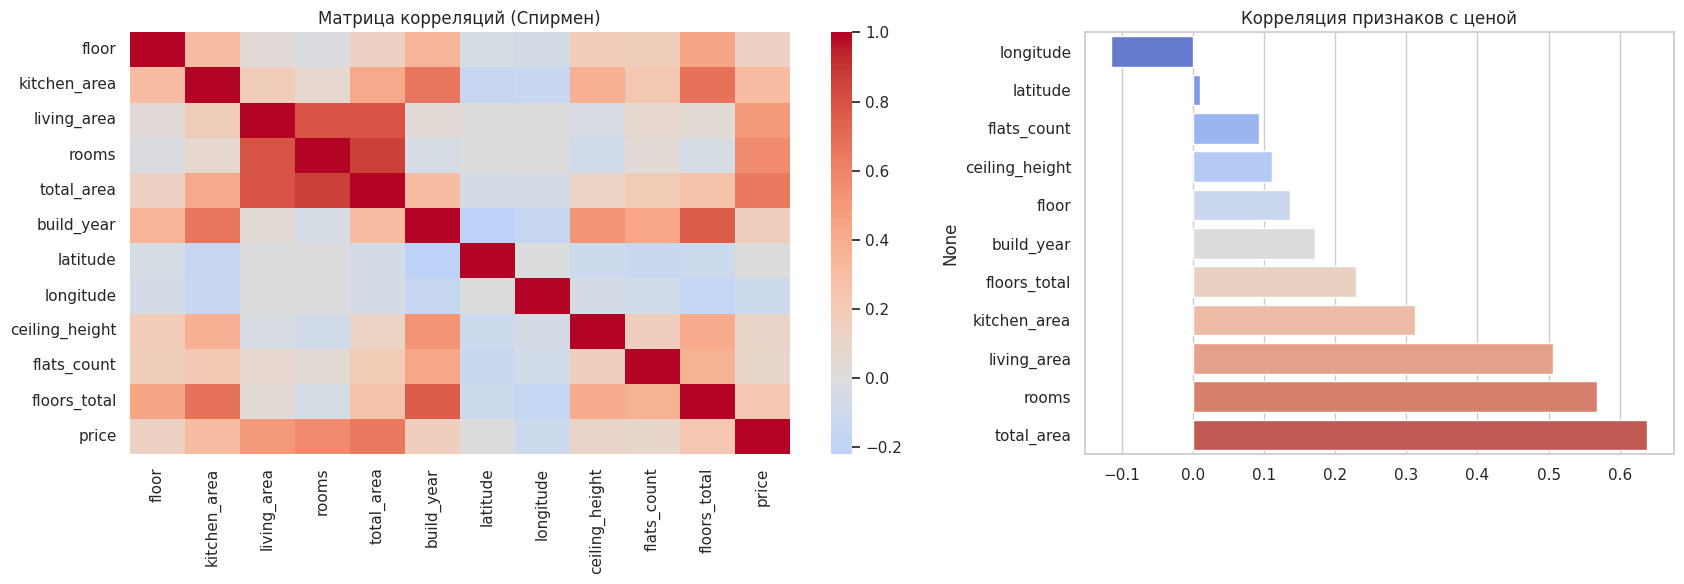

total_area        0.639
rooms             0.568
living_area       0.506
kitchen_area      0.312
floors_total      0.229
build_year        0.171
floor             0.137
ceiling_height    0.111
flats_count       0.093
latitude          0.010
longitude        -0.115
Name: price, dtype: float64

In [12]:
# 2.4 Анализ целевой переменной в зависимости от различных признаков

# корреляция Спирмена устойчива к выбросам и ловит монотонные, а не только линейные связи
corr = train[num_cols + [TARGET_COL]].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [1.4, 1]})
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Матрица корреляций (Спирмен)')

target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values()
sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette='coolwarm')
axes[1].set_title('Корреляция признаков с ценой')
fig.tight_layout()
fig.savefig(f'{ASSETS_DIR}/eda_correlations.png', dpi=110, bbox_inches='tight')
plt.show()

target_corr.sort_values(ascending=False).round(3)

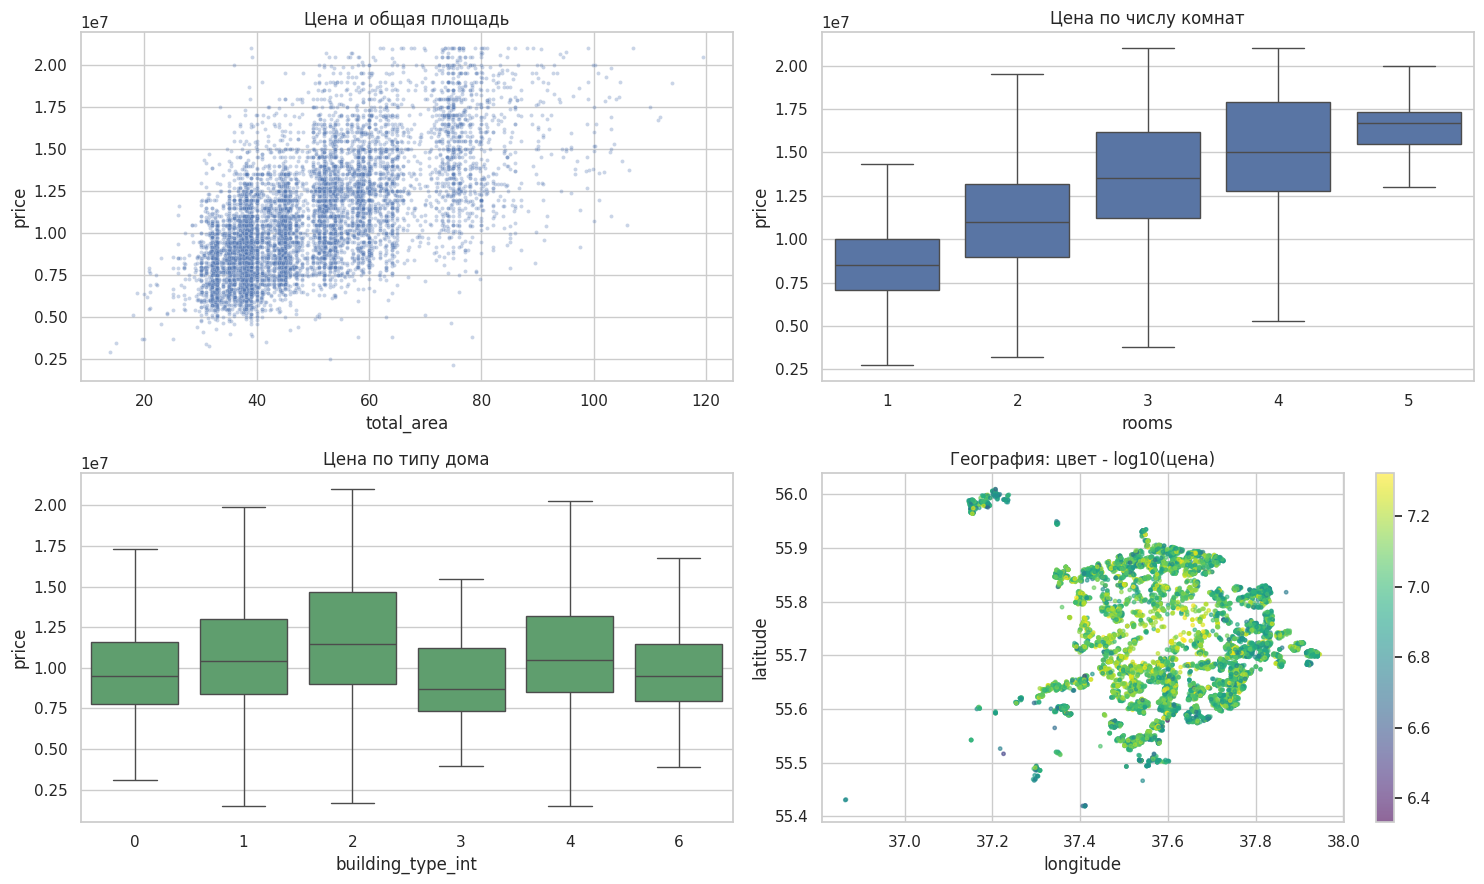

In [13]:
sample = train.sample(min(8000, len(train)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
sns.scatterplot(data=sample, x='total_area', y=TARGET_COL, s=8, alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title('Цена и общая площадь')

sns.boxplot(data=train, x='rooms', y=TARGET_COL, ax=axes[0, 1], showfliers=False, color='#4C72B0')
axes[0, 1].set_title('Цена по числу комнат')

sns.boxplot(data=train, x='building_type_int', y=TARGET_COL, ax=axes[1, 0], showfliers=False, color='#55A868')
axes[1, 0].set_title('Цена по типу дома')

geo = sample.assign(log_price=np.log10(sample[TARGET_COL]))
sc = axes[1, 1].scatter(geo['longitude'], geo['latitude'], c=geo['log_price'], cmap='viridis', s=6, alpha=0.6)
axes[1, 1].set_title('География: цвет - log10(цена)')
axes[1, 1].set_xlabel('longitude')
axes[1, 1].set_ylabel('latitude')
fig.colorbar(sc, ax=axes[1, 1])

fig.tight_layout()
fig.savefig(f'{ASSETS_DIR}/eda_target_vs_features.png', dpi=110, bbox_inches='tight')
plt.show()

In [14]:
# средняя цена и цена за квадратный метр в разрезе категорий
price_per_m2 = train[TARGET_COL] / train['total_area']
summary = train.assign(price_per_m2=price_per_m2).groupby('building_type_int').agg(
    квартир=('price', 'size'),
    медианная_цена=('price', 'median'),
    медиана_за_м2=('price_per_m2', 'median'),
    медианная_площадь=('total_area', 'median'),
).round(0)
summary

,квартир,медианная_цена,медиана_за_м2,медианная_площадь
building_type_int,,,,
0,576,9500000.0,215541.0,44.0
1,5253,10400000.0,245475.0,43.0
2,4301,11500000.0,224074.0,51.0
3,111,8700000.0,172093.0,49.0
4,50508,10500000.0,215232.0,50.0
6,5552,9500000.0,240113.0,38.0


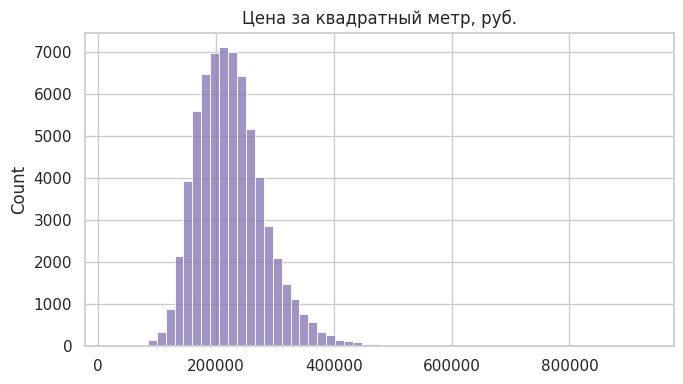

count     66,301
mean     225,200
std       58,009
min       24,074
5%       144,040
50%      219,643
95%      329,082
max      931,937
dtype: object

In [15]:
# цена за метр меняется сильно, значит одной площади модели мало - нужны признаки про локацию и дом
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(price_per_m2, bins=60, ax=ax, color='#8172B2')
ax.set_title('Цена за квадратный метр, руб.')
fig.tight_layout()
fig.savefig(f'{ASSETS_DIR}/eda_price_per_m2.png', dpi=110, bbox_inches='tight')
plt.show()

price_per_m2.describe(percentiles=[0.05, 0.5, 0.95]).apply(lambda v: f'{v:,.0f}')

#### 2.5 Выводы после EDA

Ключевые выводы (тот же текст в следующей ячейке записывается в `eda_conclusions.md` и логируется в MLflow):

1. **Цена скошена вправо умеренно и обрезана сверху.** Медиана ниже среднего, верхний процент
   объектов уходит к 20 млн руб., но резких выбросов нет — их убрал пайплайн первого спринта.
   Основной метрикой берём MAE: она считается в рублях и понятна бизнесу; модель — градиентный
   бустинг, которому не нужна нормальность распределения.

2. **Сильнее всего с ценой связаны площади.** У `total_area` и `living_area` самая высокая корреляция
   Спирмена с ценой, но между собой (и с `rooms`) они тоже сильно скоррелированы — признаки дублируют
   друг друга, поэтому отбор признаков на этапе 4 оправдан.

3. **Одной площади мало: цена за квадратный метр различается в разы.** Разброс объясняется локацией
   и характеристиками дома — на карте по `latitude`/`longitude` видно ядро дорогих объектов.
   Отсюда гипотезы для этапа 3: расстояние до центра, доли жилой и кухонной площади,
   этаж относительно этажности, возраст дома.

4. **Категориальные признаки разбалансированы.** Апартаментов и студий единицы процентов, one-hot по ним
   даёт почти константные столбцы; при этом тип дома `building_type_int` заметно влияет на медианную
   цену за м² — его оставляем.


In [16]:
# 2.5 Выводы после EDA

# те же выводы собираем в файл, чтобы залогировать их в MLflow вместе с ноутбуком
conclusions = f"""# Выводы после EDA

Датасет: {len(data):,} строк, {data.shape[1]} колонок, пропусков нет (данные уже очищены пайплайном
первого спринта). Целевая переменная - цена квартиры в рублях.

1. **Цена скошена вправо умеренно и обрезана сверху** (skew {price.skew():.1f}, максимум
   {price.max():,.0f} руб.): медиана {price.median():,.0f} руб., верхний 1% уходит за
   {price.quantile(0.99):,.0f} руб. Резких выбросов нет - их убрал пайплайн первого спринта,
   поэтому метрику можно считать на всех объектах. Основной берём MAE: она считается в рублях
   и понятна бизнесу, а модель - градиентный бустинг, ему не нужна нормальность распределения.

2. **Сильнее всего с ценой связана площадь**: корреляция Спирмена с total_area
   {target_corr['total_area']:.2f}, с living_area {target_corr['living_area']:.2f},
   с rooms {target_corr['rooms']:.2f}. При этом площадь и число комнат сильно скоррелированы между собой,
   то есть часть признаков дублирует друг друга - отбор признаков на этапе 4 имеет смысл.

3. **Одной площади мало: цена за квадратный метр гуляет в разы** (от
   {price_per_m2.quantile(0.05):,.0f} до {price_per_m2.quantile(0.95):,.0f} руб/м² между 5-м и 95-м
   перцентилем). Разброс объясняется локацией и домом: на карте по latitude/longitude видно ядро дорогих
   объектов в центре. Отсюда гипотезы для этапа 3 - расстояние до центра, доли жилой и кухонной площади,
   этаж относительно этажности, возраст дома.

4. **Категориальные признаки разбалансированы**: подавляющая часть объектов - не апартаменты и не студии,
   поэтому one-hot по ним даёт почти константные столбцы, а тип дома building_type_int заметно влияет на
   медианную цену за м² - его стоит оставить.
"""

with open(f'{ASSETS_DIR}/eda_conclusions.md', 'w', encoding='utf-8') as f:
    f.write(conclusions)

print(conclusions)

# Выводы после EDA

Датасет: 82,877 строк, 19 колонок, пропусков нет (данные уже очищены пайплайном
первого спринта). Целевая переменная - цена квартиры в рублях.

1. **Цена скошена вправо умеренно и обрезана сверху** (skew 0.6, максимум
   21,000,000 руб.): медиана 10,500,000 руб., верхний 1% уходит за
   20,000,000 руб. Резких выбросов нет - их убрал пайплайн первого спринта,
   поэтому метрику можно считать на всех объектах. Основной берём MAE: она считается в рублях
   и понятна бизнесу, а модель - градиентный бустинг, ему не нужна нормальность распределения.

2. **Сильнее всего с ценой связана площадь**: корреляция Спирмена с total_area
   0.64, с living_area 0.51,
   с rooms 0.57. При этом площадь и число комнат сильно скоррелированы между собой,
   то есть часть признаков дублирует друг друга - отбор признаков на этапе 4 имеет смысл.

3. **Одной площади мало: цена за квадратный метр гуляет в разы** (от
   144,040 до 329,082 руб/м² между 5-м и 95-м
   перцентилем). Разброс объясн

In [17]:
# 2.6 логирование артефактов в MLflow

NOTEBOOK_PATH = 'project_template_sprint_2.ipynb'

with mlflow.start_run(run_name='eda', experiment_id=EXPERIMENT_ID) as run:
    mlflow.log_params({
        'table': TABLE,
        'n_rows': len(data),
        'n_cols': data.shape[1],
        'n_train': len(X_train),
        'n_test': len(X_test),
    })
    mlflow.log_metrics({
        'target_median': float(price.median()),
        'target_mean': float(price.mean()),
        'target_skew': float(price.skew()),
        'price_per_m2_median': float(price_per_m2.median()),
    })
    # выводы и сам ноутбук
    mlflow.log_artifact(f'{ASSETS_DIR}/eda_conclusions.md', artifact_path='eda')
    mlflow.log_artifact(NOTEBOOK_PATH, artifact_path='eda')
    # графики
    for name in sorted(os.listdir(ASSETS_DIR)):
        if name.startswith('eda_') and name.endswith('.png'):
            mlflow.log_artifact(f'{ASSETS_DIR}/{name}', artifact_path='eda/plots')

print('run_id:', run.info.run_id)

run_id: c5fb1434f6964492933320298ae67707


#### Этап 3: Генерация Признаков и Обучение Новой Версии Модели
После тщательного исследовательского анализа данных (EDA), вы, скорее всего, сформировали несколько гипотез относительно новых признаков, которые могут улучшить качество вашей модели. На этом этапе, мы предлагаем вам приступить к генерации новых признаков и последующему обучению модели, используя два подхода:

Ручная генерация признаков: Используйте ваше понимание данных и результаты EDA для создания новых признаков.
Автоматическая генерация признаков: Воспользуйтесь библиотеками для автоматической генерации признаков, чтобы облегчить и ускорить этот процесс.
Важно: Для признаков, созданных вручную, рекомендуется использовать объекты sklearn, такие как Pipeline и ColumnTransformer. Это позволит автоматизировать процесс преобразования данных и облегчить поддержку вашего проекта.

После генерации новых признаков, наступает время обучить новую версию вашей модели, используя эти признаки. Не забудьте залогировать все результаты, включая новые признаки, параметры модели и метрики качества, в MLflow для удобства отслеживания изменений и результатов.

Рекомендуемые шаги:

- Определение и генерация новых признаков на основе ваших гипотез.
- Использование библиотек для автоматической генерации признаков, если это применимо.
- Интеграция новых признаков в вашу модель с помощью Pipeline или ColumnTransformer для ручно созданных признаков.
- Обучение новой версии модели с использованием всех доступных признаков.
- Логирование результатов в MLflow для документирования и анализа эффективности новых признаков и модели.

Этот этап проекта критически важен для повышения точности и эффективности вашей модели. Тщательная работа на этом этапе может существенно повлиять на итоговое качество моделирования.


In [18]:
# 3.1 ручная генерация признаков

# «нулевой год» для возраста дома - самый свежий дом в обучающей выборке
CURRENT_YEAR = int(train['build_year'].max())
# за центр города берём медианную точку, вокруг неё считаем расстояние
CENTER_LAT = float(train['latitude'].median())
CENTER_LON = float(train['longitude'].median())


def add_manual_features(df):
    """Добавляет признаки по гипотезам из EDA: планировка, этаж, дом, локация."""
    df = df.copy()

    # планировка: сколько метров на комнату и как площадь поделена между зонами
    df['area_per_room'] = df['total_area'] / df['rooms'].clip(lower=1)
    df['living_ratio'] = df['living_area'] / df['total_area']
    df['kitchen_ratio'] = df['kitchen_area'] / df['total_area']
    df['other_area'] = (df['total_area'] - df['living_area'] - df['kitchen_area']).clip(lower=0)
    df['volume'] = df['total_area'] * df['ceiling_height']

    # этаж: первый и последний традиционно дешевле, важна и относительная высота
    df['floor_ratio'] = df['floor'] / df['floors_total'].clip(lower=1)
    df['is_first_floor'] = (df['floor'] == 1).astype(int)
    df['is_last_floor'] = (df['floor'] == df['floors_total']).astype(int)

    # дом: возраст и насколько он «плотный»
    df['building_age'] = CURRENT_YEAR - df['build_year']
    df['flats_per_floor'] = df['flats_count'] / df['floors_total'].clip(lower=1)

    # локация: расстояние до центра в километрах
    lat_km = (df['latitude'] - CENTER_LAT) * 111.0
    lon_km = (df['longitude'] - CENTER_LON) * 111.0 * np.cos(np.radians(CENTER_LAT))
    df['dist_to_center'] = np.sqrt(lat_km ** 2 + lon_km ** 2)

    return df


MANUAL_FEATURES = [
    'area_per_room', 'living_ratio', 'kitchen_ratio', 'other_area', 'volume',
    'floor_ratio', 'is_first_floor', 'is_last_floor',
    'building_age', 'flats_per_floor', 'dist_to_center',
]

X_train_fe = add_manual_features(X_train)
X_train_fe[MANUAL_FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
area_per_room,66301.0,28.83,7.32,6.00,22.55,27.00,35.00,86.10
living_ratio,66301.0,0.54,0.17,0.00,0.51,0.58,0.63,0.99
kitchen_ratio,66301.0,0.18,0.05,0.03,0.14,0.17,0.21,1.00
other_area,66301.0,14.04,9.88,0.00,9.00,11.30,15.20,102.00
volume,66301.0,133.75,40.28,30.36,102.30,122.32,157.25,336.00
floor_ratio,66301.0,0.53,0.29,0.03,0.25,0.53,0.78,1.00
is_first_floor,66301.0,0.09,0.28,0.00,0.00,0.00,0.00,1.00
is_last_floor,66301.0,0.09,0.28,0.00,0.00,0.00,0.00,1.00
building_age,66301.0,37.03,17.61,0.00,21.00,41.00,53.00,97.00
flats_per_floor,66301.0,19.77,14.04,0.06,10.92,16.00,23.94,1183.00


In [19]:
# проверяем, что новые признаки вообще связаны с ценой
new_corr = (
    X_train_fe[MANUAL_FEATURES]
    .assign(price=y_train.values)
    .corr(method='spearman')['price']
    .drop('price')
    .sort_values(key=abs, ascending=False)
)
new_corr.round(3)

volume             0.640
other_area         0.432
kitchen_ratio     -0.376
area_per_room     -0.272
dist_to_center    -0.228
living_ratio       0.177
building_age      -0.171
is_first_floor    -0.100
flats_per_floor   -0.040
floor_ratio        0.026
is_last_floor     -0.026
Name: price, dtype: float64

In [20]:
# 3.2 оборачивание всех преобразований в объекты sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    OneHotEncoder,
    PolynomialFeatures,
    StandardScaler,
)
from catboost import CatBoostRegressor

# полиномы второй степени по площадям и комнатам: их произведения и квадраты хорошо
# описывают нелинейность цены от размера квартиры
POLY_COLS = ['total_area', 'living_area', 'kitchen_area', 'rooms', 'ceiling_height']
# дискретизация: год постройки и координаты удобно разложить по «корзинам» -
# так модель получает что-то вроде районов и эпох застройки
BIN_COLS = ['build_year', 'latitude', 'longitude', 'dist_to_center']
# корзины идут в дополнение к исходным значениям, а не вместо них: точные координаты
# слишком информативны, чтобы их терять. Остальное числовое просто масштабируем
SCALE_COLS = [c for c in X_train_fe.columns if c not in CAT_COLS + POLY_COLS]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('poly', PolynomialFeatures(degree=2, include_bias=False), POLY_COLS),
    ('bins', KBinsDiscretizer(n_bins=8, encode='ordinal', strategy='quantile'), BIN_COLS),
    ('num', StandardScaler(), SCALE_COLS),
])

MODEL_PARAMS = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'loss_function': 'RMSE',
    'verbose': 0,
    'thread_count': -1,
    'random_seed': RANDOM_STATE,
}


def build_pipeline(model_params=None, selector=None):
    """Собирает пайплайн: ручные признаки -> преобразования -> (отбор признаков) -> CatBoost."""
    steps = [
        ('manual', FunctionTransformer(add_manual_features)),
        ('preprocessor', clone(preprocessor)),
    ]
    if selector is not None:
        steps.append(('selector', selector))
    steps.append(('model', CatBoostRegressor(**(model_params or MODEL_PARAMS))))
    return Pipeline(steps)


# смотрим, сколько признаков получается после всех преобразований
feature_names = preprocessor.fit(X_train_fe).get_feature_names_out()
print(f'признаков было {X_train.shape[1]}, после генерации стало {len(feature_names)}')
print(list(feature_names[:15]), '...')

признаков было 15, после генерации стало 50
['cat__building_type_int_0', 'cat__building_type_int_1', 'cat__building_type_int_2', 'cat__building_type_int_3', 'cat__building_type_int_4', 'cat__building_type_int_6', 'cat__is_apartment_1', 'cat__studio_0', 'cat__has_elevator_1', 'poly__total_area', 'poly__living_area', 'poly__kitchen_area', 'poly__rooms', 'poly__ceiling_height', 'poly__total_area^2'] ...


In [21]:
# 3.3 автоматическая генерация признаков

from autofeat import AutoFeatRegressor

# autofeat перебирает комбинации признаков и отбирает полезные, это дорого по времени,
# поэтому запускаем его на подвыборке и на самых информативных числовых колонках
AF_COLS = ['total_area', 'living_area', 'kitchen_area', 'rooms', 'floor',
           'floors_total', 'build_year', 'dist_to_center']

af_sample = X_train_fe.sample(5000, random_state=RANDOM_STATE)
af_target = y_train.loc[af_sample.index]

autofeat_model = AutoFeatRegressor(feateng_steps=1, featsel_runs=2, verbose=0, n_jobs=1)
af_start = time.time()
af_transformed = autofeat_model.fit_transform(af_sample[AF_COLS], af_target)
print(f'autofeat отработал за {time.time() - af_start:.0f} c')
print(f'было {len(AF_COLS)} признаков, стало {af_transformed.shape[1]}')
autofeat_model.new_feat_cols_

autofeat отработал за 4 c
было 8 признаков, стало 12


['1/floor', 'exp(rooms)', '1/dist_to_center', 'dist_to_center**3']

In [22]:
# сравниваем на одной и той же подвыборке: исходные признаки против признаков от autofeat
from sklearn.model_selection import cross_val_score

light_params = {**MODEL_PARAMS, 'iterations': 200}


def cv_mae(X, y):
    scores = cross_val_score(
        CatBoostRegressor(**light_params), X, y,
        cv=3, scoring='neg_mean_absolute_error', n_jobs=1,
    )
    return -scores.mean()


mae_plain = cv_mae(af_sample[AF_COLS].values, af_target)
mae_autofeat = cv_mae(af_transformed.values, af_target)

autofeat_report = pd.DataFrame({
    'набор признаков': ['исходные', 'autofeat'],
    'признаков': [len(AF_COLS), af_transformed.shape[1]],
    'MAE (CV на подвыборке)': [mae_plain, mae_autofeat],
}).round(0)
autofeat_report

,набор признаков,признаков,MAE (CV на подвыборке)
0,исходные,8,1841760.0
1,autofeat,12,1844152.0


In [23]:
# сохраняем найденные autofeat формулы как артефакт: они пригодятся для отчёта и воспроизводимости
autofeat_features = {
    'input_cols': AF_COLS,
    'new_features': list(autofeat_model.new_feat_cols_),
    'cv_mae_plain': float(mae_plain),
    'cv_mae_autofeat': float(mae_autofeat),
}
with open(f'{ASSETS_DIR}/autofeat_features.json', 'w', encoding='utf-8') as f:
    json.dump(autofeat_features, f, ensure_ascii=False, indent=2)

print('\n'.join(autofeat_model.new_feat_cols_) or 'autofeat не нашёл новых признаков')

1/floor
exp(rooms)
1/dist_to_center
dist_to_center**3


In [24]:
# 3.4 обучение новой версии модели

pipeline_v2 = build_pipeline()

fit_start = time.time()
pipeline_v2.fit(X_train, y_train)
fit_time = time.time() - fit_start

pred_start = time.time()
y_pred_v2 = pipeline_v2.predict(X_test)
predict_time = time.time() - pred_start

metrics_v2 = eval_metrics(y_test, y_pred_v2)
show_metrics('после генерации признаков', metrics_v2)
print(f'\nобучение: {fit_time:.1f} c, предсказание на {len(X_test):,} объектах: {predict_time:.2f} c')

comparison = pd.DataFrame([BASELINE_METRICS, metrics_v2], index=['baseline', 'feature_generation'])
comparison['mae_прирост_%'] = (1 - comparison['mae'] / BASELINE_METRICS['mae']) * 100
comparison.round(4)

после генерации признаков
  MAE  1,661,530 руб.
  RMSE 2,057,278 руб.
  MAPE 16.18%
  R2   0.6494

обучение: 11.1 c, предсказание на 16,576 объектах: 0.25 c


,mae,rmse,mape,r2,mae_прирост_%
baseline,1.664928e+06,2.062755e+06,0.1623,0.6475,0.0000
feature_generation,1.661530e+06,2.057278e+06,0.1618,0.6494,0.2041


In [25]:
# 3.5 логирование артефактов в MLflow

from mlflow.models import infer_signature


def log_model_run(run_name, pipeline, metrics, params, extra_artifacts=(), description=None):
    """Логирует модель, параметры, метрики и артефакты, регистрирует новую версию в Model Registry."""
    with mlflow.start_run(run_name=run_name, experiment_id=EXPERIMENT_ID) as run:
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        if description:
            mlflow.set_tag('mlflow.note.content', description)

        for path in extra_artifacts:
            mlflow.log_artifact(path, artifact_path='artifacts')
        mlflow.log_artifact(NOTEBOOK_PATH, artifact_path='code')

        info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            artifact_path='model',
            signature=infer_signature(X_test.head(50), pipeline.predict(X_test.head(50))),
            input_example=X_test.head(5),
            registered_model_name=REGISTRY_MODEL_NAME,
        )
        print('run_id:', run.info.run_id)
        return info


params_v2 = {
    **MODEL_PARAMS,
    'stage': 'feature_generation',
    'n_features_in': X_train.shape[1],
    'n_features_out': len(feature_names),
    'manual_features': ', '.join(MANUAL_FEATURES),
    'poly_cols': ', '.join(POLY_COLS),
    'bin_cols': ', '.join(BIN_COLS),
    'autofeat_new_features': len(autofeat_model.new_feat_cols_),
    'fit_seconds': round(fit_time, 1),
    'predict_seconds': round(predict_time, 2),
}

log_model_run(
    run_name='feature_generation',
    pipeline=pipeline_v2,
    metrics={**metrics_v2, 'fit_time': fit_time, 'predict_time': predict_time},
    params=params_v2,
    extra_artifacts=[f'{ASSETS_DIR}/autofeat_features.json'],
    description='Ручные признаки + PolynomialFeatures + KBinsDiscretizer в ColumnTransformer, autofeat для сравнения.',
)

Registered model 'flats_price_model' already exists. Creating a new version of this model...
2026/09/23 16:53:56 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: flats_price_model, version 2


run_id: 305d41280ab74dee80e0ed5282a68994


Created version '2' of model 'flats_price_model'.


#### Этап 4: Отбор Признаков и Обучение Новой Версии Модели
Создание новых признаков — это лишь часть работы. Следующий важный шаг — это убедиться в том, что каждый из этих признаков действительно вносит положительный вклад в качество модели. Некоторые признаки могут оказывать отрицательное влияние на модель, поэтому их следует исключить из анализа.

На этом этапе, мы рекомендуем вам применить различные методы отбора признаков для того, чтобы определить и удалить те признаки, которые не улучшают качество вашей модели. Цель этого этапа — максимизировать производительность модели, удалив избыточные или неинформативные признаки.

После тщательного отбора признаков, пора обучить новую версию вашей модели, уже без негативно влияющих на неё признаков. Важно залогировать результаты этого этапа, включая измененный набор признаков, параметры модели и полученные метрики качества, в MLflow для последующего анализа и сравнения.

Рекомендуемые шаги:

- Применение методов отбора признаков для идентификации и исключения признаков, ухудшающих качество модели.
- Анализ влияния каждого признака на модель, чтобы понять, какие из них наиболее ценные.
- Обучение новой версии модели без негативно влияющих признаков.
- Логирование всех изменений и результатов в MLflow, включая конечный набор признаков, параметры модели и метрики качества.

Этот этап не только поможет улучшить качество вашей модели, но и даст глубокое понимание о важности и влиянии отдельных признаков на результаты моделирования.


In [26]:
# 4.1 Отбор признаков при помощи метода номер 1 (forward selection)

# матрицу признаков после всех преобразований отбор признаков получает уже готовой
preprocessor_fitted = build_pipeline()[:-1].fit(X_train, y_train)
feature_names = np.array(preprocessor_fitted[-1].get_feature_names_out())

Z_train = preprocessor_fitted.transform(X_train)
Z_test = preprocessor_fitted.transform(X_test)
print('матрица признаков:', Z_train.shape)

# важность признаков по обученной на этапе 3 модели
importances = pd.Series(pipeline_v2['model'].get_feature_importance(), index=feature_names)
importances = importances.sort_values(ascending=False)

TOP_N = 20
candidate_idx = np.array([list(feature_names).index(f) for f in importances.head(TOP_N).index])
print('кандидаты для отбора:', list(feature_names[candidate_idx]))

матрица признаков: (66301, 50)
кандидаты для отбора: ['num__dist_to_center', 'num__volume', 'bins__dist_to_center', 'num__latitude', 'poly__total_area^2', 'poly__total_area', 'num__longitude', 'poly__total_area rooms', 'poly__total_area ceiling_height', 'poly__total_area kitchen_area', 'bins__latitude', 'bins__longitude', 'num__floors_total', 'poly__kitchen_area rooms', 'num__building_age', 'num__build_year', 'poly__rooms ceiling_height', 'bins__build_year', 'num__floor', 'num__area_per_room']


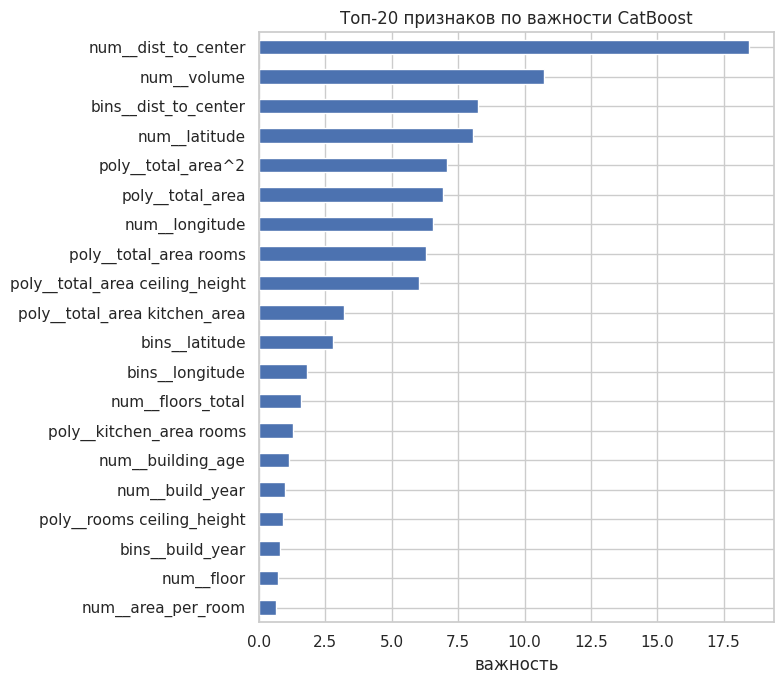

In [27]:
fig, ax = plt.subplots(figsize=(8, 7))
importances.head(TOP_N)[::-1].plot.barh(ax=ax, color='#4C72B0')
ax.set_title(f'Топ-{TOP_N} признаков по важности CatBoost')
ax.set_xlabel('важность')
fig.tight_layout()
fig.savefig(f'{ASSETS_DIR}/feature_importances.png', dpi=110, bbox_inches='tight')
plt.show()

In [28]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# на время отбора берём подвыборку и облегчённый CatBoost: методы обучают модель сотни раз
SEL_SAMPLE = 8000
sel_rows = np.random.RandomState(RANDOM_STATE).choice(len(Z_train), SEL_SAMPLE, replace=False)
Z_sel_full, y_sel = Z_train[sel_rows], y_train.values[sel_rows]
Z_sel = Z_sel_full[:, candidate_idx]

sel_estimator = CatBoostRegressor(
    iterations=100, learning_rate=0.1, depth=4, loss_function='RMSE',
    verbose=0, thread_count=-1, random_seed=RANDOM_STATE,
)

forward = SFS(
    sel_estimator,
    k_features='best',        # длину набора метод выбирает сам по метрике
    forward=True,
    floating=False,
    scoring='neg_mean_absolute_error',
    cv=2,
    n_jobs=1,
    verbose=0,
)

t0 = time.time()
forward = forward.fit(Z_sel, y_sel)
print(f'forward selection: {time.time() - t0:.0f} c')

forward_features = feature_names[candidate_idx[list(forward.k_feature_idx_)]]
print(f'отобрано {len(forward_features)} признаков, MAE на CV: {-forward.k_score_:,.0f}')
list(forward_features)

forward selection: 59 c
отобрано 11 признаков, MAE на CV: 1,738,426


['num__dist_to_center',
 'num__volume',
 'num__latitude',
 'num__longitude',
 'poly__total_area rooms',
 'poly__total_area ceiling_height',
 'poly__total_area kitchen_area',
 'bins__latitude',
 'poly__rooms ceiling_height',
 'bins__build_year',
 'num__floor']

In [29]:
# 4.2 Отбор признаков при помощи метода номер 2 (backward selection)

backward = SFS(
    sel_estimator,
    k_features='best',
    forward=False,            # стартуем со всех кандидатов и выкидываем лишние
    floating=False,
    scoring='neg_mean_absolute_error',
    cv=2,
    n_jobs=1,
    verbose=0,
)

t0 = time.time()
backward = backward.fit(Z_sel, y_sel)
print(f'backward selection: {time.time() - t0:.0f} c')

backward_features = feature_names[candidate_idx[list(backward.k_feature_idx_)]]
print(f'отобрано {len(backward_features)} признаков, MAE на CV: {-backward.k_score_:,.0f}')
list(backward_features)

backward selection: 76 c
отобрано 16 признаков, MAE на CV: 1,738,300


['num__dist_to_center',
 'num__volume',
 'num__latitude',
 'poly__total_area^2',
 'poly__total_area',
 'num__longitude',
 'poly__total_area ceiling_height',
 'poly__total_area kitchen_area',
 'num__floors_total',
 'poly__kitchen_area rooms',
 'num__building_age',
 'num__build_year',
 'poly__rooms ceiling_height',
 'bins__build_year',
 'num__floor',
 'num__area_per_room']

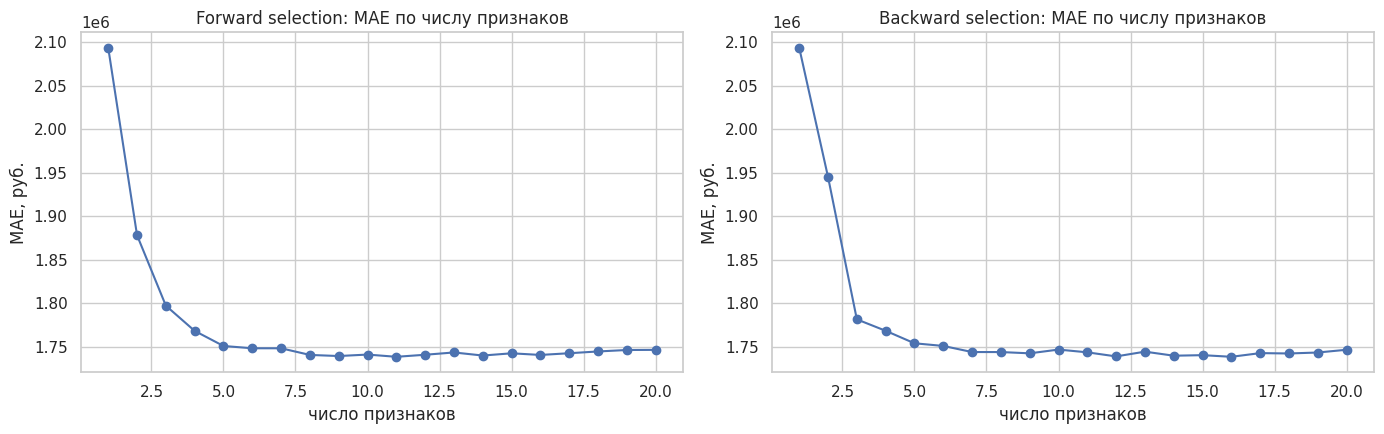

In [30]:
# 4.3 Анализ отобранных признаков и финальный список признаков для модели

# как менялось качество по ходу отбора
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, sel, title in [(axes[0], forward, 'Forward selection'), (axes[1], backward, 'Backward selection')]:
    metrics = pd.DataFrame(sel.get_metric_dict()).T
    ax.plot(metrics.index.astype(int), -metrics['avg_score'].astype(float), marker='o')
    ax.set_title(f'{title}: MAE по числу признаков')
    ax.set_xlabel('число признаков')
    ax.set_ylabel('MAE, руб.')
fig.tight_layout()
fig.savefig(f'{ASSETS_DIR}/feature_selection.png', dpi=110, bbox_inches='tight')
plt.show()

In [31]:
forward_set, backward_set = set(forward_features), set(backward_features)
both = forward_set & backward_set
either = forward_set | backward_set

print(f'forward: {len(forward_set)}, backward: {len(backward_set)}, '
      f'пересечение: {len(both)}, объединение: {len(either)}')
print('\nтолько forward:', sorted(forward_set - backward_set))
print('только backward:', sorted(backward_set - forward_set))


def cv_mae_subset(features):
    """MAE на кросс-валидации для произвольного набора признаков."""
    idx = [list(feature_names).index(f) for f in features]
    scores = cross_val_score(
        sel_estimator, Z_sel_full[:, idx], y_sel,
        cv=3, scoring='neg_mean_absolute_error', n_jobs=1,
    )
    return -scores.mean()


# у методов разные наборы, и заранее не ясно, какой лучше: пересечение самое компактное,
# объединение самое полное. Сравниваем все три на кросс-валидации и берём лучший
variants = {
    'forward': sorted(forward_set, key=lambda f: importances[f], reverse=True),
    'backward': sorted(backward_set, key=lambda f: importances[f], reverse=True),
    'пересечение': sorted(both, key=lambda f: importances[f], reverse=True),
    'объединение': sorted(either, key=lambda f: importances[f], reverse=True),
}
variant_scores = {name: cv_mae_subset(feats) for name, feats in variants.items() if feats}
display(pd.DataFrame({
    'признаков': {k: len(variants[k]) for k in variant_scores},
    'MAE (CV)': variant_scores,
}).round(0))

SELECTION_VARIANT = min(variant_scores, key=variant_scores.get)
selected_features = variants[SELECTION_VARIANT]
selected_idx = np.array([list(feature_names).index(f) for f in selected_features])

print(f'\nвыбран набор «{SELECTION_VARIANT}», признаков {len(selected_features)}:')
selected_features

forward: 11, backward: 16, пересечение: 9, объединение: 18

только forward: ['bins__latitude', 'poly__total_area rooms']
только backward: ['num__area_per_room', 'num__build_year', 'num__building_age', 'num__floors_total', 'poly__kitchen_area rooms', 'poly__total_area', 'poly__total_area^2']


,признаков,MAE (CV)
forward,11,1736591.0
backward,16,1737485.0
пересечение,9,1738067.0
объединение,18,1739499.0



выбран набор «forward», признаков 11:


['num__dist_to_center',
 'num__volume',
 'num__latitude',
 'num__longitude',
 'poly__total_area rooms',
 'poly__total_area ceiling_height',
 'poly__total_area kitchen_area',
 'bins__latitude',
 'poly__rooms ceiling_height',
 'bins__build_year',
 'num__floor']

In [32]:
# 4.4 Обучение новой версии модели

from mlxtend.feature_selection import ColumnSelector

# ColumnSelector встраивается в тот же пайплайн: преобразования -> отбор колонок -> модель
pipeline_v3 = build_pipeline(selector=ColumnSelector(cols=tuple(selected_idx)))

t0 = time.time()
pipeline_v3.fit(X_train, y_train)
fit_time_v3 = time.time() - t0

t0 = time.time()
y_pred_v3 = pipeline_v3.predict(X_test)
predict_time_v3 = time.time() - t0

metrics_v3 = eval_metrics(y_test, y_pred_v3)
show_metrics('после отбора признаков', metrics_v3)
print(f'\nобучение: {fit_time_v3:.1f} c, предсказание: {predict_time_v3:.2f} c')

comparison = pd.DataFrame(
    [BASELINE_METRICS, metrics_v2, metrics_v3],
    index=['baseline', 'feature_generation', 'feature_selection'],
)
comparison['mae_прирост_%'] = (1 - comparison['mae'] / BASELINE_METRICS['mae']) * 100
comparison.round(4)

после отбора признаков
  MAE  1,665,130 руб.
  RMSE 2,062,512 руб.
  MAPE 16.23%
  R2   0.6476

обучение: 4.9 c, предсказание: 0.05 c


,mae,rmse,mape,r2,mae_прирост_%
baseline,1.664928e+06,2.062755e+06,0.1623,0.6475,0.0000
feature_generation,1.661530e+06,2.057278e+06,0.1618,0.6494,0.2041
feature_selection,1.665130e+06,2.062512e+06,0.1623,0.6476,-0.0122


In [33]:
# 4.5 Логирование всех артефактов в MLflow

# сохраняем список отобранных признаков как артефакт
selection_report = {
    'candidates': list(feature_names[candidate_idx]),
    'forward': list(forward_features),
    'backward': list(backward_features),
    'selected': selected_features,
    'variant_cv_mae': {k: float(v) for k, v in variant_scores.items()},
    'variant_chosen': SELECTION_VARIANT,
    'forward_cv_mae': float(-forward.k_score_),
    'backward_cv_mae': float(-backward.k_score_),
}
with open(f'{ASSETS_DIR}/selected_features.json', 'w', encoding='utf-8') as f:
    json.dump(selection_report, f, ensure_ascii=False, indent=2)

params_v3 = {
    **MODEL_PARAMS,
    'stage': 'feature_selection',
    'selection_methods': 'mlxtend SFS forward + backward',
    'selection_variant': SELECTION_VARIANT,
    'n_features_before': len(feature_names),
    'n_features_after': len(selected_features),
    'selected_features': ', '.join(selected_features)[:490],
    'fit_seconds': round(fit_time_v3, 1),
    'predict_seconds': round(predict_time_v3, 2),
}

log_model_run(
    run_name='feature_selection',
    pipeline=pipeline_v3,
    metrics={**metrics_v3, 'fit_time': fit_time_v3, 'predict_time': predict_time_v3},
    params=params_v3,
    extra_artifacts=[
        f'{ASSETS_DIR}/selected_features.json',
        f'{ASSETS_DIR}/feature_importances.png',
        f'{ASSETS_DIR}/feature_selection.png',
    ],
    description='Отбор признаков mlxtend: forward + backward, финальный набор - пересечение методов.',
)

Registered model 'flats_price_model' already exists. Creating a new version of this model...
2026/09/23 16:56:23 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: flats_price_model, version 3


run_id: 7038990c7a104d94b36a96b17822e66a


Created version '3' of model 'flats_price_model'.


### Этап 5 - подбор гиперпараметров и обучение новой версии модели
После того как мы уделили значительное внимание качеству модели через создание и отбор признаков, пришло время для финального штриха — подбора гиперпараметров. Этот этап является ключевым в финальной части проекта второго спринта, где ваша задача — оптимизировать гиперпараметры модели для достижения наилучшего качества.

Рекомендуется подобрать гиперпараметры как минимум двумя различными методами (например, с использованием Grid Search и Random Search), чтобы вы могли сравнить результаты и выбрать наиболее эффективный набор гиперпараметров для вашей модели. После определения оптимальных гиперпараметров, наступает время обучить финальную версию модели, используя ваши новые признаки.

Рекомендуемые шаги:

- Выбор методов для подбора гиперпараметров: Определитесь с методами, которые вы будете использовать для подбора гиперпараметров (например, Grid Search, Random Search, Bayesian Optimization).
- Подбор гиперпараметров: Примените выбранные методы для нахождения оптимальных значений гиперпараметров вашей модели.
- Сравнение результатов: Анализируйте и сравнивайте результаты, полученные различными методами, для определения наилучшего набора гиперпараметров.
- Обучение финальной модели: Используя выбранные гиперпараметры, обучите финальную версию вашей модели на новых признаках.
- Документирование процесса и результатов: Залогируйте все шаги и результаты в MLflow, включая сравнение методов подбора гиперпараметров и характеристики финальной модели.

Этот этап позволит вам максимально улучшить качество вашей модели перед финальной оценкой, предоставив полное понимание важности и влияния гиперпараметров на производительность модели.

In [34]:
# 5.1 Подбор гиперпараметров при помощи метода номер 1: optuna

import optuna
from optuna.integration.mlflow import MLflowCallback
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# подбор гоняет модель десятки раз, поэтому работаем на подвыборке train с отобранными признаками
TUNE_SAMPLE = 15000
tune_rows = np.random.RandomState(RANDOM_STATE).choice(len(Z_train), TUNE_SAMPLE, replace=False)
Z_tune, y_tune = Z_train[tune_rows][:, selected_idx], y_train.values[tune_rows]

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def cv_mae_params(params):
    """MAE на кросс-валидации для набора гиперпараметров."""
    model = CatBoostRegressor(
        verbose=0, thread_count=-1, random_seed=RANDOM_STATE, **params
    )
    scores = cross_val_score(model, Z_tune, y_tune, cv=cv, scoring='neg_mean_absolute_error', n_jobs=1)
    return -scores.mean()


def objective(trial):
    params = {
        # обучение прямо под MAE обычно даёт по этой метрике выигрыш, но считается дольше -
        # пусть оптимизатор сам решит, стоит ли оно того
        'loss_function': trial.suggest_categorical('loss_function', ['RMSE', 'MAE']),
        'iterations': trial.suggest_int('iterations', 300, 1200, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
    }
    return cv_mae_params(params)


mlflow_callback = MLflowCallback(
    tracking_uri=TRACKING_URI,
    metric_name='cv_mae',
    create_experiment=False,
    mlflow_kwargs={'experiment_id': EXPERIMENT_ID, 'nested': True},
)

with mlflow.start_run(run_name='hyperopt_optuna', experiment_id=EXPERIMENT_ID) as optuna_run:
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name='catboost_optuna',
    )
    t0 = time.time()
    study.optimize(objective, n_trials=15, callbacks=[mlflow_callback])
    optuna_time = time.time() - t0

    mlflow.log_params({f'best_{k}': v for k, v in study.best_params.items()})
    mlflow.log_metrics({'best_cv_mae': study.best_value, 'search_seconds': optuna_time})
    mlflow.set_tag('method', 'optuna TPE')

print(f'optuna: {optuna_time:.0f} c, лучший MAE на CV: {study.best_value:,.0f}')
study.best_params

optuna: 385 c, лучший MAE на CV: 1,702,504


{'loss_function': 'RMSE',
 'iterations': 1200,
 'learning_rate': 0.02169924677745687,
 'depth': 9,
 'l2_leaf_reg': 1.0778717335941141,
 'min_data_in_leaf': 38}

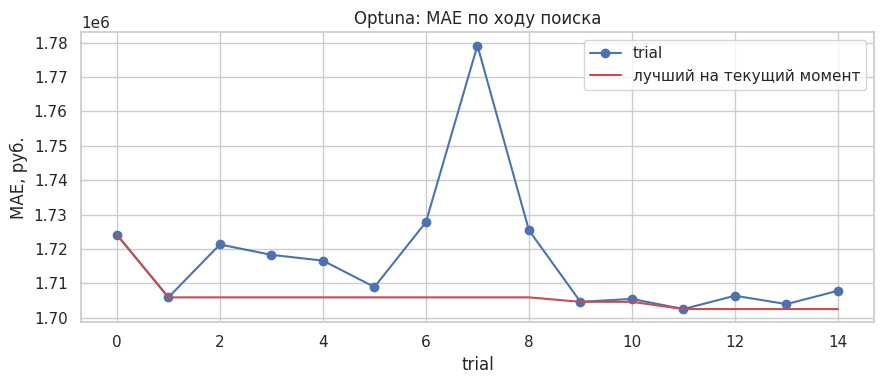

,trial,cv_mae,loss_function,iterations,learning_rate,depth,l2_leaf_reg,min_data_in_leaf
11,11,1.702504e+06,RMSE,1200,0.0217,9,1.0779,38
13,13,1.703954e+06,RMSE,1200,0.0303,9,4.5362,48
9,9,1.704613e+06,RMSE,800,0.0277,9,1.6710,50
10,10,1.705466e+06,RMSE,800,0.0204,9,1.1311,37
1,1,1.705909e+06,RMSE,1000,0.0210,10,8.4920,11


In [35]:
# как шёл поиск: значение метрики по номеру trial
history = pd.DataFrame([
    {'trial': t.number, 'cv_mae': t.value, **t.params}
    for t in study.trials if t.value is not None
])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history['trial'], history['cv_mae'], marker='o', label='trial')
ax.plot(history['trial'], history['cv_mae'].cummin(), color='#C44E52', label='лучший на текущий момент')
ax.set_title('Optuna: MAE по ходу поиска')
ax.set_xlabel('trial')
ax.set_ylabel('MAE, руб.')
ax.legend()
fig.tight_layout()
fig.savefig(f'{ASSETS_DIR}/optuna_history.png', dpi=110, bbox_inches='tight')
plt.show()

history.sort_values('cv_mae').head().round(4)

In [36]:
# 5.2 Подбор гиперпараметров при помощи метода номер 2: RandomizedSearchCV

param_distributions = {
    'iterations': [300, 500, 700, 900, 1100],
    'learning_rate': [0.02, 0.05, 0.08, 0.1, 0.15, 0.2],
    'depth': [4, 5, 6, 7, 8, 9, 10],
    'l2_leaf_reg': [1.0, 3.0, 5.0, 7.0, 10.0],
    'min_data_in_leaf': [1, 5, 10, 20, 50],
    # MAE - наша основная метрика, стоит проверить, поможет ли обучение прямо под неё
    'loss_function': ['RMSE', 'MAE'],
}

search = RandomizedSearchCV(
    CatBoostRegressor(loss_function='RMSE', verbose=0, thread_count=-1, random_seed=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

with mlflow.start_run(run_name='hyperopt_random_search', experiment_id=EXPERIMENT_ID) as rs_run:
    t0 = time.time()
    search.fit(Z_tune, y_tune)
    rs_time = time.time() - t0

    mlflow.log_params({f'best_{k}': v for k, v in search.best_params_.items()})
    mlflow.log_metrics({'best_cv_mae': -search.best_score_, 'search_seconds': rs_time})
    mlflow.set_tag('method', 'sklearn RandomizedSearchCV')

    # полную таблицу переборов сохраняем артефактом
    cv_results = pd.DataFrame(search.cv_results_)
    cv_results.to_csv(f'{ASSETS_DIR}/random_search_results.csv', index=False)
    mlflow.log_artifact(f'{ASSETS_DIR}/random_search_results.csv', artifact_path='artifacts')

print(f'random search: {rs_time:.0f} c, лучший MAE на CV: {-search.best_score_:,.0f}')
search.best_params_

random search: 129 c, лучший MAE на CV: 1,710,246


{'min_data_in_leaf': 1,
 'loss_function': 'RMSE',
 'learning_rate': 0.05,
 'l2_leaf_reg': 3.0,
 'iterations': 1100,
 'depth': 8}

In [37]:
# 5.3 Формирование списка гиперпараметров для новой модели

methods = pd.DataFrame([
    {'метод': 'optuna (TPE)', 'MAE на CV': study.best_value, 'секунд': optuna_time, 'params': study.best_params},
    {'метод': 'random search', 'MAE на CV': -search.best_score_, 'секунд': rs_time, 'params': search.best_params_},
])
display(methods[['метод', 'MAE на CV', 'секунд']].round(0))

best_row = methods.loc[methods['MAE на CV'].idxmin()]
BEST_PARAMS = {
    'loss_function': 'RMSE',
    'verbose': 0,
    'thread_count': -1,
    'random_seed': RANDOM_STATE,
    **best_row['params'],
}
print('берём параметры метода:', best_row['метод'])
BEST_PARAMS

,метод,MAE на CV,секунд
0,optuna (TPE),1702504.0,385.0
1,random search,1710246.0,129.0


берём параметры метода: optuna (TPE)


{'loss_function': 'RMSE',
 'verbose': 0,
 'thread_count': -1,
 'random_seed': 42,
 'iterations': 1200,
 'learning_rate': 0.02169924677745687,
 'depth': 9,
 'l2_leaf_reg': 1.0778717335941141,
 'min_data_in_leaf': 38}

In [38]:
# 5.4 Обучение финальной версии модели

pipeline_v4 = build_pipeline(
    model_params=BEST_PARAMS,
    selector=ColumnSelector(cols=tuple(selected_idx)),
)

t0 = time.time()
pipeline_v4.fit(X_train, y_train)
fit_time_v4 = time.time() - t0

t0 = time.time()
y_pred_v4 = pipeline_v4.predict(X_test)
predict_time_v4 = time.time() - t0

metrics_v4 = eval_metrics(y_test, y_pred_v4)
show_metrics('финальная модель', metrics_v4)
print(f'\nобучение: {fit_time_v4:.1f} c, предсказание: {predict_time_v4:.2f} c')

финальная модель
  MAE  1,639,116 руб.
  RMSE 2,029,011 руб.
  MAPE 15.99%
  R2   0.6590

обучение: 28.0 c, предсказание: 0.11 c


,mae,rmse,mape,r2,"MAE к baseline, %"
1. baseline,1.664928e+06,2.062755e+06,0.1623,0.6475,0.0000
2. генерация признаков,1.661530e+06,2.057278e+06,0.1618,0.6494,0.2041
3. отбор признаков,1.665130e+06,2.062512e+06,0.1623,0.6476,-0.0122
4. подбор гиперпараметров,1.639116e+06,2.029011e+06,0.1599,0.6590,1.5503


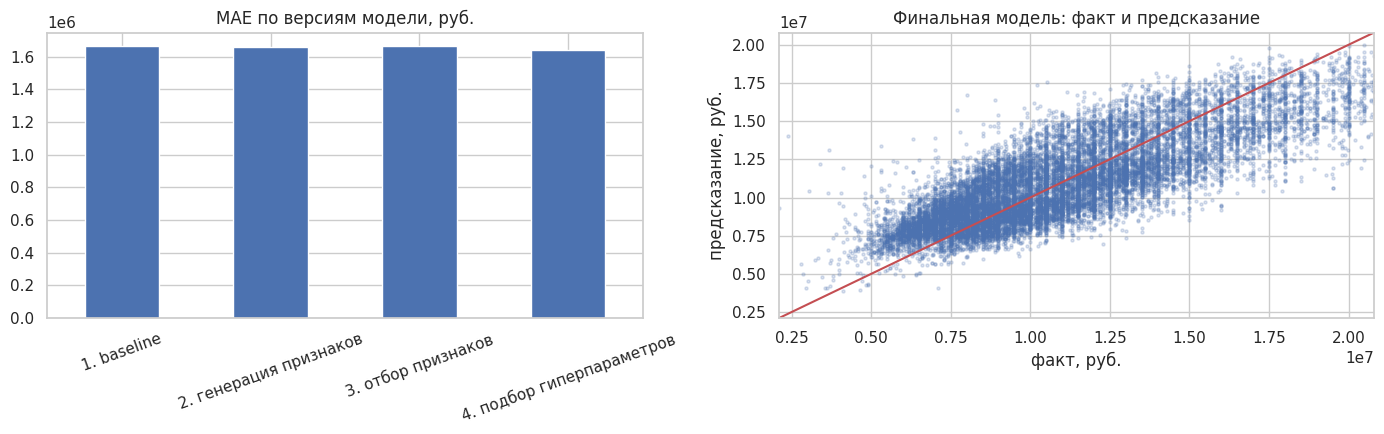

In [39]:
all_metrics = pd.DataFrame(
    [BASELINE_METRICS, metrics_v2, metrics_v3, metrics_v4],
    index=['1. baseline', '2. генерация признаков', '3. отбор признаков', '4. подбор гиперпараметров'],
)
all_metrics['MAE к baseline, %'] = (1 - all_metrics['mae'] / BASELINE_METRICS['mae']) * 100
all_metrics.to_csv(f'{ASSETS_DIR}/models_comparison.csv')
display(all_metrics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
all_metrics['mae'].plot.bar(ax=axes[0], color='#4C72B0', rot=20)
axes[0].set_title('MAE по версиям модели, руб.')
axes[0].set_xlabel('')

axes[1].scatter(y_test, y_pred_v4, s=5, alpha=0.2)
lims = [y_test.min(), y_test.quantile(0.995)]
axes[1].plot(lims, lims, color='#C44E52')
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_title('Финальная модель: факт и предсказание')
axes[1].set_xlabel('факт, руб.')
axes[1].set_ylabel('предсказание, руб.')
fig.tight_layout()
fig.savefig(f'{ASSETS_DIR}/final_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

In [40]:
# 5.5 Логирование артефактов в MLflow

params_v4 = {
    **BEST_PARAMS,
    'stage': 'hyperparameters',
    'tuning_methods': 'optuna TPE + RandomizedSearchCV',
    'tuning_winner': best_row['метод'],
    'optuna_trials': len(study.trials),
    'random_search_iters': 10,
    'n_features': len(selected_features),
    'fit_seconds': round(fit_time_v4, 1),
    'predict_seconds': round(predict_time_v4, 2),
}

improvement = (1 - metrics_v4['mae'] / BASELINE_METRICS['mae']) * 100

log_model_run(
    run_name='final_model',
    pipeline=pipeline_v4,
    metrics={
        **metrics_v4,
        'fit_time': fit_time_v4,
        'predict_time': predict_time_v4,
        'mae_improvement_pct': improvement,
    },
    params=params_v4,
    extra_artifacts=[
        f'{ASSETS_DIR}/models_comparison.csv',
        f'{ASSETS_DIR}/optuna_history.png',
        f'{ASSETS_DIR}/final_comparison.png',
    ],
    description=(
        'Финальная модель: ручные + полиномиальные + дискретизированные признаки, отбор mlxtend, '
        f'гиперпараметры подобраны методами optuna и RandomizedSearchCV. '
        f'MAE лучше baseline на {improvement:.1f}%.'
    ),
)

Registered model 'flats_price_model' already exists. Creating a new version of this model...
2026/09/23 17:05:29 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: flats_price_model, version 4


run_id: ae7bf98205584ab8ac4111f92b9b799c


Created version '4' of model 'flats_price_model'.


In [41]:
# что в итоге лежит в Model Registry
from mlflow import MlflowClient

client = MlflowClient()
versions = pd.DataFrame([
    {
        'версия': v.version,
        'run_name': client.get_run(v.run_id).data.tags.get('mlflow.runName'),
        'MAE': round(float(client.get_run(v.run_id).data.metrics['mae'])),
    }
    for v in client.search_model_versions(f"name = '{REGISTRY_MODEL_NAME}'")
]).sort_values('версия')
versions

,версия,run_name,MAE
3,1,baseline_model,1664928
2,2,feature_generation,1661530
1,3,feature_selection,1665130
0,4,final_model,1639116


## Итоги

Все четыре версии модели лежат в MLflow Model Registry под именем `flats_price_model`,
все запуски — в одном эксперименте `flats_price_improvement`:

| Этап | Запуск в MLflow | Версия модели |
|---|---|---|
| Baseline первого спринта | `baseline_model` | 1 |
| EDA | `eda` | — |
| Генерация признаков | `feature_generation` | 2 |
| Отбор признаков | `feature_selection` | 3 |
| Подбор гиперпараметров | `hyperopt_optuna`, `hyperopt_random_search`, `final_model` | 4 |